## This is a notebook for our churn prediction model pipeline

### Connect to Google BigQuery Database

### Look at features - EDA

### Feature engineering - Customer segmentation (Kmeans), Time series analysis

### Model selection

### Model evaulation


In [1]:
import gc
import time
import platform
import os
from dataclasses import dataclass
from typing import Callable, Any, List, Dict

import numpy as np
import pandas as pd

from google.cloud import bigquery
import db_dtypes

import sklearn
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

from imblearn.over_sampling import SMOTE
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score, recall_score, classification_report
import shap

from sklearn.decomposition import PCA
from imblearn.over_sampling import SMOTE
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

E0000 00:00:1773171547.611430 73654357 instrument.cc:563] Metric with name 'grpc.resource_quota.calls_dropped' registered more than once. Ignoring later registration.
E0000 00:00:1773171547.611575 73654357 instrument.cc:563] Metric with name 'grpc.resource_quota.calls_rejected' registered more than once. Ignoring later registration.
E0000 00:00:1773171547.611577 73654357 instrument.cc:563] Metric with name 'grpc.resource_quota.connections_dropped' registered more than once. Ignoring later registration.
E0000 00:00:1773171547.611586 73654357 instrument.cc:563] Metric with name 'grpc.resource_quota.instantaneous_memory_pressure' registered more than once. Ignoring later registration.
E0000 00:00:1773171547.611588 73654357 instrument.cc:563] Metric with name 'grpc.resource_quota.memory_pressure_control_value' registered more than once. Ignoring later registration.


### Configure bigquery credentials

#### you may need to download gcloud - run 'brew install --cask google-cloud-sdk' and follow instructions to add to path

#### change the sql query to get different joined tables


In [2]:
PROJECT_ID = 'netflix-user-behavior'
# can add different queries based on what we need. 
# project id stays the same 
SQL = os.environ.get(
    "BQ_SQL",
    """
select * from `netflix-user-behavior.kaggle_cleaned.churn_features` 
    """.strip()
)

print("PROJECT_ID:", PROJECT_ID)
print("SQL preview:\n", SQL[:300], "..." if len(SQL) > 300 else "")

PROJECT_ID: netflix-user-behavior
SQL preview:
 select * from `netflix-user-behavior.kaggle_cleaned.churn_features` 


In [3]:
# load in data from bigquery to pandas dataframe.
def load_bigquery_to_pandas(project_id: str, sql: str) -> pd.DataFrame:
	# authenticates using google credentials and connects to bigquery
	client = bigquery.Client(project=project_id)
    # sends request to bigquery and returns QueryJob object
	job = client.query(sql)
	df = job.result().to_dataframe()
	return df

pdf = load_bigquery_to_pandas(PROJECT_ID, SQL) 
pdf.head()
pdf.columns[pdf.isna().any()]
# change all na values to 0
pdf.fillna(0, inplace=True)



/opt/miniconda3/envs/netflix-env/lib/python3.12/site-packages/google/auth/_default.py:114: UserWarning: Your application has authenticated using end user credentials from Google Cloud SDK without a quota project. You might receive a "quota exceeded" or "API not enabled" error. See the following page for troubleshooting: https://cloud.google.com/docs/authentication/adc-troubleshooting/user-creds. 
  warnings.warn(_CLOUD_SDK_CREDENTIALS_WARNING)


In [4]:
# check for na and df shape
pdf.columns[pdf.isna().any()]
pdf.shape

(6735, 23)

In [5]:
# detect categorical columns and one hot encode them 
categorical_columns = pdf.select_dtypes(include=['object']).columns
print(categorical_columns)

# one hot encode gender, primary device, subscription plan, only user_id is an object now
pdf = pd.get_dummies(pdf, columns=['gender', 'primary_device', 'subscription_plan'], drop_first=True)


Index(['user_id', 'gender', 'primary_device', 'subscription_plan'], dtype='object')


### Recency, Frequency, Engagement (RFE) segmentation based on Behavioral Data


In [6]:

# we will try RFE segmentation first using kmeans clustering 
# columns picked with heuristics 

rfe_cols = [
    "days_since_last_watch",   # recency
    "total_sessions",          # frequency
    "avg_completion_rate"      # engagement
]

X_rfe = pdf[rfe_cols]

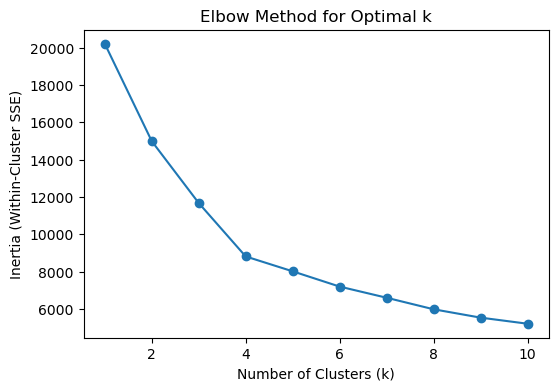

In [7]:
# standardize features 
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_rfe)

# run elbow plot first 
# compute inertia for different k
inertia = []
K = range(1, 11)

for k in K:
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(X_scaled)
    inertia.append(kmeans.inertia_)

# plot elbow curve
plt.figure(figsize=(6,4))
plt.plot(K, inertia, marker='o')
plt.xlabel("Number of Clusters (k)")
plt.ylabel("Inertia (Within-Cluster SSE)")
plt.title("Elbow Method for Optimal k")
plt.show()



In [8]:
# we will use 4 clusters 
kmeans = KMeans(n_clusters=4, random_state=42)
pdf["segment"] = kmeans.fit_predict(X_scaled)

In [9]:
# profile each cluster
segment_profile = pdf.groupby("segment")[rfe_cols].mean()
print(segment_profile)

         days_since_last_watch  total_sessions  avg_completion_rate
segment                                                            
0                    56.783648        8.547275            40.839445
1                     42.47204       13.712343            49.783087
2                   221.735739        7.696158            50.795277
3                    53.302914        8.731964            58.072148


## cluster description (mean for each cluster):

#### 0: days since last watch: 56, total sessions: 8, average completion rate: 41

#### 'Browsing users': users that log in relatively frequently but just browse

#### Business action: send personalized recommendations, make it easier to find content, improve recommendation

#### --

#### 1: days since last watch: 42, total sessions: 13, average completion rate: 49

#### 'Regular viewers': 0 is the most active, they have the highest average total sessions and relatively high completion rate

#### Business action: offer premium features, recommend new movies

#### --

#### 2: days since last watch: 222, total sessions: 7, average completion rate: 50

#### 'Dormant users': haven't watched in a while, likely churned

#### Business action: send promotions (cheaper deals), send targeted messages

#### --

#### 3: days since last watch: 53, total sessions: 8, average completion rate: 58

#### 'Quality viewers': less frequent watchers but when they do, they spend a longer time watching

#### Business action: personalized recommendations, notify of similar content


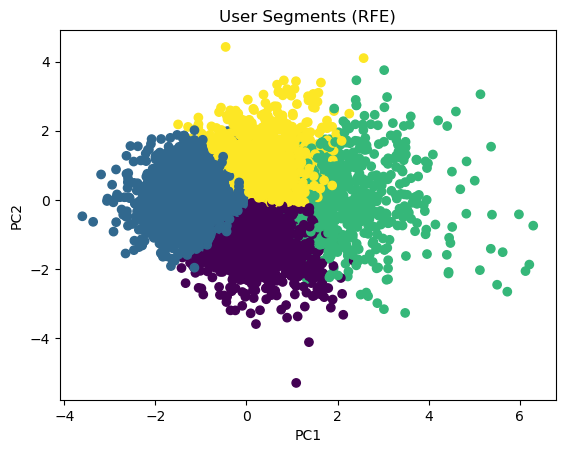

In [10]:
# visualize clusters with PCA

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

plt.scatter(X_pca[:,0], X_pca[:,1], c=pdf["segment"])
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("User Segments (RFE)")
plt.show()

In [11]:
pdf.head()

,user_id,age,is_active,days_since_last_watch,watch_last_7d,watch_last_30d,engagement_ratio_7v30,total_sessions,total_watch_minutes,avg_completion_rate,...,gender_Unknown,primary_device_Gaming Console,primary_device_Laptop,primary_device_Mobile,primary_device_Smart TV,primary_device_Tablet,subscription_plan_Premium,subscription_plan_Premium+,subscription_plan_Standard,segment
0,user_00003,32.0,False,190,0.0,0.0,0.0,8,594.2,43.437500,...,False,False,False,False,False,False,False,False,True,2
1,user_01600,45.0,True,538,0.0,0.0,0.0,2,246.8,34.650000,...,False,True,False,False,False,False,False,False,False,2
2,user_07168,18.0,True,274,0.0,0.0,0.0,7,267.1,52.057143,...,False,False,False,False,False,False,False,False,True,2
3,user_01811,43.0,True,94,0.0,0.0,0.0,9,1288.5,47.922222,...,False,False,False,False,False,False,True,False,False,0
4,user_02216,25.0,False,257,0.0,0.0,0.0,9,979.1,48.755556,...,False,False,False,False,False,False,False,False,True,2


# Feature Engineering for Churn Model - ignore section (all this was done in sql already)


In [12]:
'''
# Convert watch_date to datetime objects for calculation
pdf['watch_date'] = pd.to_datetime(pdf['watch_date'])
# Sort data chronologically per user to maintain behavioral sequence
pdf = pdf.sort_values(['user_id', 'watch_date'])

# Feature 1: Calculate content completion rate
# Ratio of duration watched vs. total movie duration (clipped at 1.0 to handle data noise)
pdf['completion_rate'] = (pdf['watch_duration_minutes'] / (pdf['duration_minutes'] + 1e-9)).clip(upper=1.0)

# Feature 2: Calculate tenure at the moment of watching
# Measure how many days have passed since subscription at each watch event
temp_pdf = pd.merge(pdf, user[['user_id', 'subscription_start_date']], on='user_id', how='left')
pdf['days_since_signup'] = (pdf['watch_date'] - pd.to_datetime(temp_pdf['subscription_start_date'])).dt.days

# Defining Reference Points for Recency and Trends
latest_date = pdf['watch_date'].max() # get the most recent date 
seven_days_ago = latest_date - pd.Timedelta(days=7) # define the threshold for recent behavior (last 7 days)

# Feature 3: Calculate recency
# Days since the user's very last watch event (High value = High churn risk)
recency = pdf.groupby('user_id')['watch_date'].max().reset_index()
recency['days_since_last_watch'] = (latest_date - recency['watch_date']).dt.days

# Feature 4: Calculate recent watch volume (Last 7 days)
recent_7d = pdf[pdf['watch_date'] >= seven_days_ago].groupby('user_id')['watch_duration_minutes'].sum().reset_index() # sum of watch duration within the last 7 days of the dataset
recent_7d.columns = ['user_id', 'recent_7d_watch_sum']

# Summarizing the raw logs into a single row per user
user_watch_stats = pdf.groupby('user_id').agg({
    'movie_id': 'count',
    'watch_duration_minutes': ['sum', 'mean'],
    'completion_rate': 'mean',
    'days_since_signup': 'max' # Final tenure at their last watch event
}).reset_index()

# Flatten the multi-index columns for easier access
user_watch_stats.columns = ['user_id', 'movie_id_count', 'total_watch_sum', 'watch_mean', 'completion_rate_mean', 'max_tenure_at_watch']

# Combine all aggregated stats, recency, and recent trends
final_user_features = pd.merge(user_watch_stats, recency[['user_id', 'days_since_last_watch']], on='user_id', how='left')
final_user_features = pd.merge(final_user_features, recent_7d, on='user_id', how='left').fillna(0)

# Feature 5: Calculate watch decline ratio (Churn Signal)
# Compares activity in the last 7 days vs. the overall weekly average
# A ratio near 0 indicates a sharp drop in activity
final_user_features['watch_decline_ratio'] = final_user_features['recent_7d_watch_sum'] / (final_user_features['total_watch_sum'] / 4 + 1e-9)
'''

"\n# Convert watch_date to datetime objects for calculation\npdf['watch_date'] = pd.to_datetime(pdf['watch_date'])\n# Sort data chronologically per user to maintain behavioral sequence\npdf = pdf.sort_values(['user_id', 'watch_date'])\n\n# Feature 1: Calculate content completion rate\n# Ratio of duration watched vs. total movie duration (clipped at 1.0 to handle data noise)\npdf['completion_rate'] = (pdf['watch_duration_minutes'] / (pdf['duration_minutes'] + 1e-9)).clip(upper=1.0)\n\n# Feature 2: Calculate tenure at the moment of watching\n# Measure how many days have passed since subscription at each watch event\ntemp_pdf = pd.merge(pdf, user[['user_id', 'subscription_start_date']], on='user_id', how='left')\npdf['days_since_signup'] = (pdf['watch_date'] - pd.to_datetime(temp_pdf['subscription_start_date'])).dt.days\n\n# Defining Reference Points for Recency and Trends\nlatest_date = pdf['watch_date'].max() # get the most recent date \nseven_days_ago = latest_date - pd.Timedelta(days=

In [13]:
'''
# Merge with User Profile
final_user_df = pd.merge(user, final_user_features, on='user_id', how='left').fillna(0)

# Feature 6: Content Value Metric (Total watch time / Monthly fee)
# High value means the user feels they are getting their money's worth
final_user_df['total_content_value'] = final_user_df['total_watch_sum'] / (final_user_df['monthly_spend'] + 1e-9)

# Feature 7: Total Account Tenure
# Total days since the user first joined until the "baseline" date
final_user_df['total_tenure_days'] = (latest_date - pd.to_datetime(final_user_df['subscription_start_date'])).dt.days

print(f"Final Data Shape: {final_user_df.shape}")
final_user_df.head()
'''

'\n# Merge with User Profile\nfinal_user_df = pd.merge(user, final_user_features, on=\'user_id\', how=\'left\').fillna(0)\n\n# Feature 6: Content Value Metric (Total watch time / Monthly fee)\n# High value means the user feels they are getting their money\'s worth\nfinal_user_df[\'total_content_value\'] = final_user_df[\'total_watch_sum\'] / (final_user_df[\'monthly_spend\'] + 1e-9)\n\n# Feature 7: Total Account Tenure\n# Total days since the user first joined until the "baseline" date\nfinal_user_df[\'total_tenure_days\'] = (latest_date - pd.to_datetime(final_user_df[\'subscription_start_date\'])).dt.days\n\nprint(f"Final Data Shape: {final_user_df.shape}")\nfinal_user_df.head()\n'

# Prepare Train, Test Data


In [14]:
'''

# Exclude IDs and dates
ignore_cols = [
    # IDs and personal information
    'user_id', 'email', 'first_name', 'last_name', 'household_size',
    # location info
    'state_province', 'city', 'country', 'location_country', 
    # unrelated info
    'is_active', 'monthly_spend', 'age', 'gender', 'created_at', 
    'subscription_plan', 'primary_device', 'imdb_rating_mean', 
    # variables for target
    'watch_decline_ratio', 'recent_7d_watch_sum' 
]

# Define target: if watch_decline_ratio < 0.2, we identified them as high risk for churn
final_user_df['churn_risk'] = (final_user_df['watch_decline_ratio'] < 0.2).astype(int)

# Check target distribution 
print(final_user_df['churn_risk'].value_counts(normalize=True))

# Define X, y
target = 'churn_risk'
cols_to_drop = [c for c in ignore_cols + [target] if c in final_user_df.columns]

X = final_user_df.drop(columns=cols_to_drop)
y = final_user_df['churn_risk']

# One Hot Encoding
X = pd.get_dummies(X, drop_first=True)

# Convert non-numeric features as numeric 
X = X.apply(pd.to_numeric, errors='coerce')

# Handle NaNs
X = X.dropna(axis=1, how='any')
X = X.replace([np.inf, -np.inf], np.nan) # replace infinite values as NaN
X = X.fillna(0) # fill NaN as 0 

X = X.astype(float)

# Split data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Standardization
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Oversampling the training data only 
smote = SMOTE(sampling_strategy=0.2, random_state=42)
X_train_resampled, y_train_resampled = smote.fit_resample(X_train_scaled, y_train)
'''

"\n\n# Exclude IDs and dates\nignore_cols = [\n    # IDs and personal information\n    'user_id', 'email', 'first_name', 'last_name', 'household_size',\n    # location info\n    'state_province', 'city', 'country', 'location_country', \n    # unrelated info\n    'is_active', 'monthly_spend', 'age', 'gender', 'created_at', \n    'subscription_plan', 'primary_device', 'imdb_rating_mean', \n    # variables for target\n    'watch_decline_ratio', 'recent_7d_watch_sum' \n]\n\n# Define target: if watch_decline_ratio < 0.2, we identified them as high risk for churn\nfinal_user_df['churn_risk'] = (final_user_df['watch_decline_ratio'] < 0.2).astype(int)\n\n# Check target distribution \nprint(final_user_df['churn_risk'].value_counts(normalize=True))\n\n# Define X, y\ntarget = 'churn_risk'\ncols_to_drop = [c for c in ignore_cols + [target] if c in final_user_df.columns]\n\nX = final_user_df.drop(columns=cols_to_drop)\ny = final_user_df['churn_risk']\n\n# One Hot Encoding\nX = pd.get_dummies(X, dro

In [15]:

# Define target: if watch_decline_ratio < 0.2, we identified them as high risk for churn
pdf['churn_risk'] = (pdf['watch_decline_ratio'] < 0.2).astype(int)

# Check target distribution 
print(pdf['churn_risk'].value_counts(normalize=True))

target = 'churn_risk'
cols_to_drop = ['user_id', 'watch_decline_ratio', 'watch_last_7d', 'total_watch_minutes', 'is_active'] 

# remove the target and the id field from the feature set
X = pdf.drop(columns=cols_to_drop + [target])
y = pdf['churn_risk']

# Convert non-numeric features as numeric 
X = X.apply(pd.to_numeric, errors='coerce')

X = X.astype(float)
print(X.info())

# Split data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Standardization
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Oversampling the training data only 
smote = SMOTE(sampling_strategy=0.2, random_state=42)
X_train_resampled, y_train_resampled = smote.fit_resample(X_train_scaled, y_train)


churn_risk
1    0.919376
0    0.080624
Name: proportion, dtype: float64
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6735 entries, 0 to 6734
Data columns (total 28 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   age                            6735 non-null   float64
 1   days_since_last_watch          6735 non-null   float64
 2   watch_last_30d                 6735 non-null   float64
 3   engagement_ratio_7v30          6735 non-null   float64
 4   total_sessions                 6735 non-null   float64
 5   avg_completion_rate            6735 non-null   float64
 6   rec_click_rate                 6735 non-null   float64
 7   avg_rec_score_seen             6735 non-null   float64
 8   total_searches                 6735 non-null   float64
 9   avg_search_time                6735 non-null   float64
 10  avg_search_click_rate          6735 non-null   float64
 11  avg_rating_given               6735 

In [16]:
print(y_train_resampled.value_counts(normalize=True))

churn_risk
1    0.833445
0    0.166555
Name: proportion, dtype: float64


# Logistic Regression


In [17]:
# Logistic Regression using Elastic Net
model = LogisticRegression(
    penalty='elasticnet', 
    solver='saga',  # Make sure we use elastic net
    l1_ratio=0.5, 
    random_state=42,
    max_iter=100 #5000
)
model.fit(X_train_resampled, y_train_resampled)

# Metrics
y_pred = model.predict(X_test_scaled)
print(f"Accuracy:  {accuracy_score(y_test, y_pred):.4f}")
print(f"Recall:    {recall_score(y_test, y_pred):.4f}")
print(f"F1 Score:  {f1_score(y_test, y_pred):.4f}")
coeffs = pd.Series(model.coef_[0], index=X.columns)
important_features = coeffs[coeffs != 0].sort_values(ascending=False)
print("\n Important features")
print(important_features)

print(classification_report(y_test, y_pred))

Accuracy:  0.9733
Recall:    0.9782
F1 Score:  0.9854

 Important features
days_since_last_watch            3.148226e+00
total_sessions                   4.391601e-01
avg_sentiment_score              2.658678e-01
gender_Prefer not to say         2.465059e-01
subscription_plan_Premium+       2.457878e-01
tenure_days                      2.325189e-01
avg_rec_score_seen               1.925409e-01
primary_device_Mobile            1.848267e-01
gender_Unknown                   1.772983e-01
gender_Male                      1.393209e-01
segment                          1.294195e-01
avg_search_time                  8.900250e-02
primary_device_Laptop            6.735187e-02
age                              6.172581e-02
gender_Other                     1.054604e-02
subscription_plan_Standard      -3.037467e-08
primary_device_Smart TV         -9.637272e-03
primary_device_Gaming Console   -2.932964e-02
total_searches                  -3.061475e-02
avg_completion_rate             -3.607387e-02
rec_c

/opt/miniconda3/envs/netflix-env/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
/opt/miniconda3/envs/netflix-env/lib/python3.12/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


# Random Forest


In [18]:
# RF model initilization
rf_model = RandomForestClassifier(
    n_estimators=1000,      
    max_depth=None,          
    random_state=42,
    class_weight='balanced'
)

# Model training
rf_model.fit(X_train_resampled, y_train_resampled)

# Probability based prediction
y_probs = rf_model.predict_proba(X_test_scaled)
y_probs_0 = y_probs[:, 0]  # focus on the probability of being 'Churn Risk (0)'


# Custom threshold calibration
# In our case (churn prediction), catching a potential leaver (Recall) is more important 
# than being perfectly precise. We lower the threshold to 0.3.
# If probability of Churn (0) > 30%, we flag the user as Risk (0).
threshold = 0.3
y_pred_custom = [0 if p > threshold else 1 for p in y_probs_0]

# Performance Evaluation
print(f"Evaluation with threshold: {threshold}")
print(classification_report(y_test, y_pred_custom))

# Feature importance analysis
importances = pd.Series(rf_model.feature_importances_, index=X.columns)
print("\n RF Important Features")
print(importances.sort_values(ascending=False).head(10))

Evaluation with threshold: 0.3
              precision    recall  f1-score   support

           0       0.91      0.98      0.94       109
           1       1.00      0.99      0.99      1238

    accuracy                           0.99      1347
   macro avg       0.95      0.99      0.97      1347
weighted avg       0.99      0.99      0.99      1347


 RF Important Features
engagement_ratio_7v30    0.399973
days_since_last_watch    0.338153
watch_last_30d           0.193542
total_sessions           0.009548
segment                  0.007551
avg_completion_rate      0.006377
monthly_spend            0.004537
total_searches           0.004357
avg_search_time          0.004332
tenure_days              0.004232
dtype: float64


# XGBoost


In [19]:


# Model initialization
xgb_model = XGBClassifier(
    n_estimators=500,
    max_depth=6,           
    learning_rate=0.05,    
    scale_pos_weight=1, 
    random_state=42,
    use_label_encoder=False,
    eval_metric='logloss' # standard loss function for binary
)

# Model training
xgb_model.fit(X_train_resampled, y_train_resampled)

# Evaluating performance using the default probability threshold
y_pred_xgb = xgb_model.predict(X_test_scaled)

print("XGBoost Baseline Performance (Threshold 0.5)")
print(classification_report(y_test, y_pred_xgb))

# Custom Threshold Calibration (Threshold 0.4) 
# Extracting raw probabilities for Churn Risk (0) to fine-tune Sensitivity (Recall).
# If the probability of being a leaver is > 40%, we flag them.
y_probs_xgb = xgb_model.predict_proba(X_test_scaled)[:, 0]  # probability of class 0
y_pred_xgb_custom = [0 if p > 0.4 else 1 for p in y_probs_xgb]

print("\n XGBoost Optimized Performance (Threshold 0.4)")
print(classification_report(y_test, y_pred_xgb_custom))

/opt/miniconda3/envs/netflix-env/lib/python3.12/site-packages/xgboost/training.py:200: UserWarning: [12:39:25] WARNING: /Users/runner/miniforge3/conda-bld/xgboost-split_1772125106903/work/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


XGBoost Baseline Performance (Threshold 0.5)
              precision    recall  f1-score   support

           0       0.95      0.94      0.95       109
           1       1.00      1.00      1.00      1238

    accuracy                           0.99      1347
   macro avg       0.97      0.97      0.97      1347
weighted avg       0.99      0.99      0.99      1347


 XGBoost Optimized Performance (Threshold 0.4)
              precision    recall  f1-score   support

           0       0.95      0.96      0.96       109
           1       1.00      1.00      1.00      1238

    accuracy                           0.99      1347
   macro avg       0.98      0.98      0.98      1347
weighted avg       0.99      0.99      0.99      1347



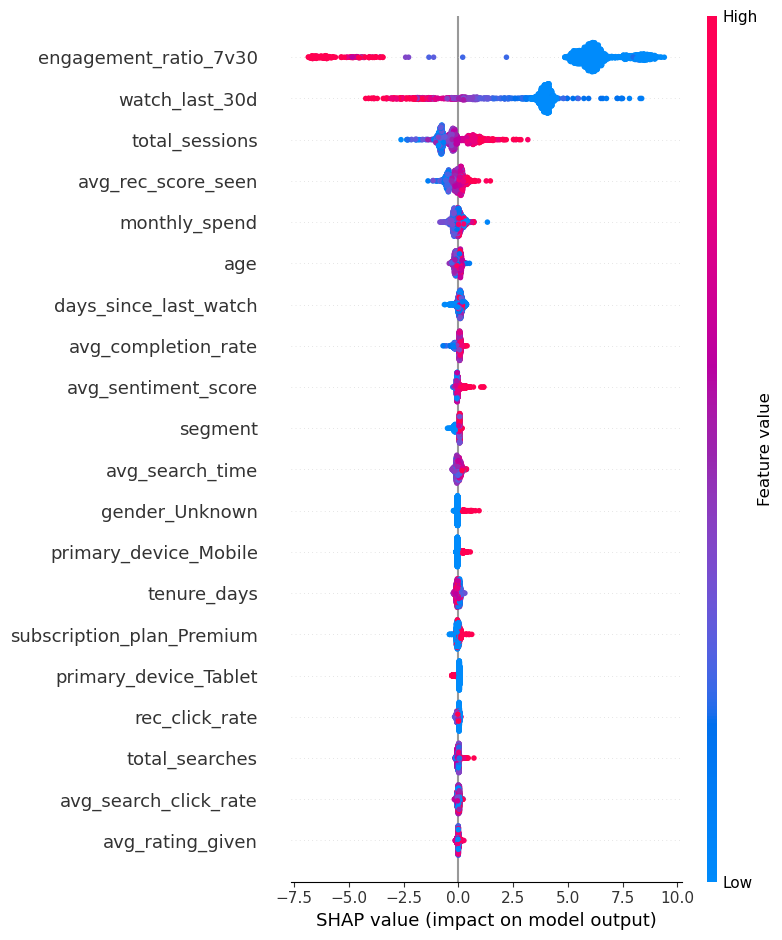

In [20]:

# Create SHAP Explainer and pass the XGBoost model 
explainer = shap.TreeExplainer(xgb_model)

# Calculate SHAP value
shap_values = explainer.shap_values(X_test_scaled)

# Make summary plot to show which variables were important factors for decisions
shap.summary_plot(shap_values, X_test, feature_names=X.columns)